In [75]:
import sys
print(sys.executable)

c:\Users\Windows 10\AppData\Local\Programs\Python\Python312\python.exe


In [76]:
import pandas as pd
import numpy as np

In [77]:
df = pd.read_csv('D:\emi_prediction_dataset.csv')

<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_6084\3706709170.py:1: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv('D:\emi_prediction_dataset.csv')
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_6084\3706709170.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\emi_prediction_dataset.csv')


In [78]:
df.shape

(404800, 27)

In [79]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [80]:
print(df.dtypes)

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees                 int64
college_fees                int64
travel_expenses             int64
groceries_utilities         int64
other_monthly_expenses      int64
existing_loans             object
current_emi_amount          int64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount            int64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object


In [81]:
df.select_dtypes(include=['int64', 'float64','object']).columns.tolist()

['age',
 'gender',
 'marital_status',
 'education',
 'monthly_salary',
 'employment_type',
 'years_of_employment',
 'company_type',
 'house_type',
 'monthly_rent',
 'family_size',
 'dependents',
 'school_fees',
 'college_fees',
 'travel_expenses',
 'groceries_utilities',
 'other_monthly_expenses',
 'existing_loans',
 'current_emi_amount',
 'credit_score',
 'bank_balance',
 'emergency_fund',
 'emi_scenario',
 'requested_amount',
 'requested_tenure',
 'emi_eligibility',
 'max_monthly_emi']

In [82]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (15): ['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (12): ['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']


In [83]:
print(df['education'].unique())

['Professional' 'Graduate' 'High School' 'Post Graduate' nan]


In [84]:
missing_count = df.isnull().sum()
print(missing_count)

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64


In [85]:
# Percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct)

age                       0.000000
gender                    0.000000
marital_status            0.000000
education                 0.593874
monthly_salary            0.000000
employment_type           0.000000
years_of_employment       0.000000
company_type              0.000000
house_type                0.000000
monthly_rent              0.599308
family_size               0.000000
dependents                0.000000
school_fees               0.000000
college_fees              0.000000
travel_expenses           0.000000
groceries_utilities       0.000000
other_monthly_expenses    0.000000
existing_loans            0.000000
current_emi_amount        0.000000
credit_score              0.597826
bank_balance              0.599308
emergency_fund            0.580781
emi_scenario              0.000000
requested_amount          0.000000
requested_tenure          0.000000
emi_eligibility           0.000000
max_monthly_emi           0.000000
dtype: float64


In [86]:
# Combine both and show only columns with missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

                Missing Count  Missing Percentage
monthly_rent             2426            0.599308
bank_balance             2426            0.599308
credit_score             2420            0.597826
education                2404            0.593874
emergency_fund           2351            0.580781


In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.describe()

,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


In [89]:
df[df.duplicated()]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi


In [90]:
for col in categorical_cols:
    print(f"{col} : {df[col].nunique()} unique values")
    print(f"  Values: {df[col].unique()}")
    print("-" * 50)

age : 33 unique values
  Values: [38 58 48 32 27 47 37 31 59 49 33 26 39 57 28 '58' '38' '48' '32' '27'
 '37' '33' '49' '31' '39' '47' '59' '57' '26' '28' '58.0.0' '38.0.0'
 '32.0.0']
--------------------------------------------------
gender : 8 unique values
  Values: ['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
--------------------------------------------------
marital_status : 2 unique values
  Values: ['Married' 'Single']
--------------------------------------------------
education : 4 unique values
  Values: ['Professional' 'Graduate' 'High School' 'Post Graduate' nan]
--------------------------------------------------
monthly_salary : 13662 unique values
  Values: ['82600' '21500' '86100' ... '56779' '56280' '55905']
--------------------------------------------------
employment_type : 3 unique values
  Values: ['Private' 'Government' 'Self-employed']
--------------------------------------------------
company_type : 5 unique values
  Values: ['Mid-size' 'MNC' 'Startup

In [91]:
# Check target variable distribution — classification
print(df['emi_eligibility'].value_counts())
print("\n")
print(df['emi_eligibility'].value_counts(normalize=True) * 100)

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64


emi_eligibility
Not_Eligible    77.289526
Eligible        18.390316
High_Risk        4.320158
Name: proportion, dtype: float64


In [92]:
print(df['max_monthly_emi'].describe())

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


In [93]:
# Check correlation of numerical columns with target (selling_price)
print(df[numerical_cols].corr()['max_monthly_emi'].sort_values(ascending=False))

max_monthly_emi           1.000000
groceries_utilities       0.484695
travel_expenses           0.440948
emergency_fund            0.415231
other_monthly_expenses    0.382055
credit_score              0.229441
years_of_employment       0.028887
requested_tenure          0.001006
requested_amount         -0.002034
dependents               -0.062266
family_size              -0.062266
monthly_rent             -0.170097
school_fees              -0.215234
current_emi_amount       -0.242434
college_fees             -0.258842
Name: max_monthly_emi, dtype: float64


In [94]:
# Check cardinality — high cardinality columns need special treatment
for col in categorical_cols:
    print(f"{col} : {df[col].nunique()} unique values")

age : 33 unique values
gender : 8 unique values
marital_status : 2 unique values
education : 4 unique values
monthly_salary : 13662 unique values
employment_type : 3 unique values
company_type : 5 unique values
house_type : 3 unique values
existing_loans : 2 unique values
bank_balance : 12261 unique values
emi_scenario : 5 unique values
emi_eligibility : 3 unique values


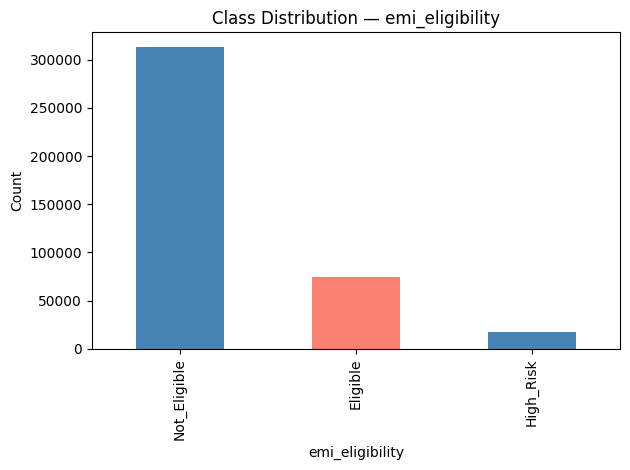

In [95]:
# Check class imbalance for classification target
import matplotlib.pyplot as plt

df['emi_eligibility'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution — emi_eligibility')
plt.xlabel('emi_eligibility')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

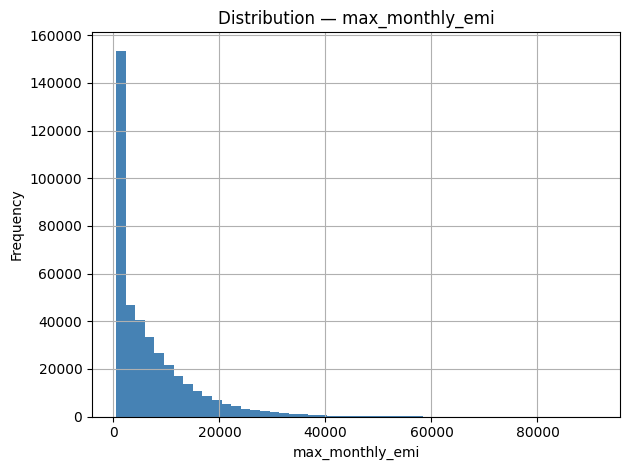

In [96]:
# Check distribution of regression target
df['max_monthly_emi'].hist(bins=50, color='steelblue')
plt.title('Distribution — max_monthly_emi')
plt.xlabel('max_monthly_emi')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [97]:
# Check skewness of numerical columns
print(df[numerical_cols].skew().sort_values(ascending=False))

years_of_employment       2.147970
max_monthly_emi           1.974159
emergency_fund            1.790000
current_emi_amount        1.777650
monthly_rent              1.612384
college_fees              1.539982
other_monthly_expenses    1.404994
requested_amount          1.386145
travel_expenses           1.355937
groceries_utilities       1.228968
requested_tenure          0.918680
school_fees               0.584345
family_size               0.022211
dependents                0.022211
credit_score             -1.094064
dtype: float64


In [98]:
# Final summary of data exploration
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Numerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")
print(f"Class Balance ('emi_eligibility'):\n{df['emi_eligibility'].value_counts()}")

Total Rows: 404800
Total Columns: 27
Numerical Columns: 15
Categorical Columns: 12
Total Missing Values: 12027
Total Duplicate Rows: 0
Class Balance ('emi_eligibility'):
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64


In [99]:
# Check missing values with percentage
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

                Missing Count  Missing Percentage
monthly_rent             2426            0.599308
bank_balance             2426            0.599308
credit_score             2420            0.597826
education                2404            0.593874
emergency_fund           2351            0.580781


In [100]:
import pandas as pd

# Columns to check (only numeric ones)
cols_to_check = ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']

# Step 1: Convert to numeric (invalid values → NaN)
df[cols_to_check] = df[cols_to_check].apply(pd.to_numeric, errors='coerce')

# Step 2: (Optional) Handle missing values after conversion
# You can choose mean/median depending on skew
df[cols_to_check] = df[cols_to_check].fillna(df[cols_to_check].median())

# Step 3: Calculate skewness
skew_values = df[cols_to_check].skew()

print("Skewness of numeric columns:\n")
print(skew_values)

Skewness of numeric columns:

monthly_rent      1.620951
bank_balance      1.428576
credit_score     -1.097378
emergency_fund    1.798757
dtype: float64


In [101]:
print(df['education'].unique())

['Professional' 'Graduate' 'High School' 'Post Graduate' nan]


In [102]:
cols_to_check = ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']
df[cols_to_check] = df[cols_to_check].apply(pd.to_numeric, errors='coerce')
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df)*100, 2)}%)")

monthly_rent — Outliers: 12720 (3.14%)
bank_balance — Outliers: 13499 (3.33%)
credit_score — Outliers: 5840 (1.44%)
emergency_fund — Outliers: 17790 (4.39%)


In [103]:
median_cols = ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

print("Median imputation done!")

Median imputation done!


In [104]:
# Impute categorical columns with Mode
cat_impute_cols = ['education']

for col in cat_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Mode imputation done!")

Mode imputation done!


In [105]:
print(df['education'].unique())

['Professional' 'Graduate' 'High School' 'Post Graduate']


In [106]:
# Verify no missing values remain
print(df.isnull().sum().sum())

0


In [107]:
# Check and drop duplicate rows
print(f"Before dropping duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"After dropping duplicates: {df.shape}")

Before dropping duplicates: (404800, 27)
After dropping duplicates: (404800, 27)


In [108]:
# Check data types
print(df.dtypes)

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees                 int64
college_fees                int64
travel_expenses             int64
groceries_utilities         int64
other_monthly_expenses      int64
existing_loans             object
current_emi_amount          int64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount            int64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object


In [109]:
# Fix data types

df['gender'] = df['gender'].astype('category')
df['marital_status'] = df['marital_status'].astype('category')
df['education'] = df['education'].astype('category')
df['employment_type'] = df['employment_type'].astype('category')
df['years_of_employment'] = df['years_of_employment'].astype('int64')
df['company_type'] = df['company_type'].astype('category')
df['house_type'] = df['house_type'].astype('category')
df['credit_score'] = df['credit_score'].astype('int64')
df['emi_eligibility'] = df['emi_eligibility'].astype('category')

# Verify
print(df.dtypes)

age                         object
gender                    category
marital_status            category
education                 category
monthly_salary              object
employment_type           category
years_of_employment          int64
company_type              category
house_type                category
monthly_rent               float64
family_size                  int64
dependents                   int64
school_fees                  int64
college_fees                 int64
travel_expenses              int64
groceries_utilities          int64
other_monthly_expenses       int64
existing_loans              object
current_emi_amount           int64
credit_score                 int64
bank_balance               float64
emergency_fund             float64
emi_scenario                object
requested_amount             int64
requested_tenure             int64
emi_eligibility           category
max_monthly_emi            float64
dtype: object


In [110]:
# Check inconsistent values in categorical columns
for col in categorical_cols:
    print(f"{col} : {df[col].unique()}")
    print("-" * 50)

age : [38 58 48 32 27 47 37 31 59 49 33 26 39 57 28 '58' '38' '48' '32' '27'
 '37' '33' '49' '31' '39' '47' '59' '57' '26' '28' '58.0.0' '38.0.0'
 '32.0.0']
--------------------------------------------------
gender : ['Female', 'Male', 'female', 'male', 'M', 'MALE', 'F', 'FEMALE']
Categories (8, object): ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'female', 'male']
--------------------------------------------------
marital_status : ['Married', 'Single']
Categories (2, object): ['Married', 'Single']
--------------------------------------------------
education : ['Professional', 'Graduate', 'High School', 'Post Graduate']
Categories (4, object): ['Graduate', 'High School', 'Post Graduate', 'Professional']
--------------------------------------------------
monthly_salary : ['82600' '21500' '86100' ... '56779' '56280' '55905']
--------------------------------------------------
employment_type : ['Private', 'Government', 'Self-employed']
Categories (3, object): ['Government', 'Private', 

In [111]:
df['age'] = df['age'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()
df['monthly_salary'] = df['monthly_salary'].astype(str).str.replace(r'\.0+','', regex=True).str.strip()


In [112]:
print(df['age'].unique())
print(df['monthly_salary'].unique())

['38' '58' '48' '32' '27' '47' '37' '31' '59' '49' '33' '26' '39' '57'
 '28']
['82600' '21500' '86100' ... '56779' '56280' '55905']


In [113]:
df['age'] = df['age'].astype('int64')
df['monthly_salary'] = df['monthly_salary'].astype('float64')

In [114]:
# Update numerical and categorical columns after dtype changes
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")



Numerical columns (18): ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']
Categorical columns (9): ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'emi_eligibility']


In [115]:
import pandas as pd

columns = ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'emi_eligibility']
unique_values = {}

for col in columns:
    if col in df.columns:
        unique_values[col] = sorted(df[col].dropna().astype(str).unique())
    else:
        unique_values[col] = []

print("Unique values for each column:\n")
for col, values in unique_values.items():
    print(f"{col}: {values}\n")

Unique values for each column:

gender: ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'female', 'male']

marital_status: ['Married', 'Single']

education: ['Graduate', 'High School', 'Post Graduate', 'Professional']

employment_type: ['Government', 'Private', 'Self-employed']

company_type: ['Large Indian', 'MNC', 'Mid-size', 'Small', 'Startup']

house_type: ['Family', 'Own', 'Rented']

existing_loans: ['No', 'Yes']

emi_scenario: ['E-commerce Shopping EMI', 'Education EMI', 'Home Appliances EMI', 'Personal Loan EMI', 'Vehicle EMI']

emi_eligibility: ['Eligible', 'High_Risk', 'Not_Eligible']



In [116]:
df.columns = df.columns.str.strip()

category_map = {
    'F': 'female',
    'FEMALE': 'female',
    'f': 'female',
    'female': 'female',
    'Female': 'female',
    
    'M': 'male',
    'MALE': 'male',
    'Male': 'male',
    'male': 'male',
    'm': 'male'
}

df['gender'] = df['gender'].replace(category_map)

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_6084\847037724.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['gender'] = df['gender'].replace(category_map)


In [117]:
print(df['gender'].unique())

['female', 'male']
Categories (2, object): ['female', 'male']


In [118]:
df['education'].unique()

['Professional', 'Graduate', 'High School', 'Post Graduate']
Categories (4, object): ['Graduate', 'High School', 'Post Graduate', 'Professional']

In [119]:
# Check skewness of all numerical columns
print(df[numerical_cols].skew().sort_values(ascending=False))

monthly_salary            4.831152
years_of_employment       2.141366
max_monthly_emi           1.974159
emergency_fund            1.798757
current_emi_amount        1.777650
monthly_rent              1.620951
college_fees              1.539982
bank_balance              1.428576
other_monthly_expenses    1.404994
requested_amount          1.386145
travel_expenses           1.355937
groceries_utilities       1.228968
requested_tenure          0.918680
age                       0.652411
school_fees               0.584345
family_size               0.022211
dependents                0.022211
credit_score             -1.097378
dtype: float64


In [120]:
# Check outliers using IQR for all numerical columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df)*100, 2)}%)")

age — Outliers: 0 (0.0%)
monthly_salary — Outliers: 12120 (2.99%)
years_of_employment — Outliers: 21236 (5.25%)
monthly_rent — Outliers: 12720 (3.14%)
family_size — Outliers: 0 (0.0%)
dependents — Outliers: 0 (0.0%)
school_fees — Outliers: 0 (0.0%)
college_fees — Outliers: 48000 (11.86%)
travel_expenses — Outliers: 12465 (3.08%)
groceries_utilities — Outliers: 11774 (2.91%)
other_monthly_expenses — Outliers: 13518 (3.34%)
current_emi_amount — Outliers: 17351 (4.29%)
credit_score — Outliers: 5840 (1.44%)
bank_balance — Outliers: 13499 (3.33%)
emergency_fund — Outliers: 17790 (4.39%)
requested_amount — Outliers: 25883 (6.39%)
requested_tenure — Outliers: 7730 (1.91%)
max_monthly_emi — Outliers: 17268 (4.27%)


In [121]:
# Cap outliers using Winsorization (IQR method)
cols_to_cap = ['monthly_salary', 'travel_expenses', 'groceries_utilities'
               ,'other_monthly_expenses','bank_balance','emergency_fund','requested_amount','requested_tenure']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping done!")

Outlier capping done!


In [122]:
# Verify outliers after capping
for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col} — Outliers remaining: {outliers}")

monthly_salary — Outliers remaining: 0
travel_expenses — Outliers remaining: 0
groceries_utilities — Outliers remaining: 0
other_monthly_expenses — Outliers remaining: 0
bank_balance — Outliers remaining: 0
emergency_fund — Outliers remaining: 0
requested_amount — Outliers remaining: 0
requested_tenure — Outliers remaining: 0


In [123]:
# Check outliers using IQR for all numerical columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df)*100, 2)}%)")

age — Outliers: 0 (0.0%)
monthly_salary — Outliers: 0 (0.0%)
years_of_employment — Outliers: 21236 (5.25%)
monthly_rent — Outliers: 12720 (3.14%)
family_size — Outliers: 0 (0.0%)
dependents — Outliers: 0 (0.0%)
school_fees — Outliers: 0 (0.0%)
college_fees — Outliers: 48000 (11.86%)
travel_expenses — Outliers: 0 (0.0%)
groceries_utilities — Outliers: 0 (0.0%)
other_monthly_expenses — Outliers: 0 (0.0%)
current_emi_amount — Outliers: 17351 (4.29%)
credit_score — Outliers: 5840 (1.44%)
bank_balance — Outliers: 0 (0.0%)
emergency_fund — Outliers: 0 (0.0%)
requested_amount — Outliers: 0 (0.0%)
requested_tenure — Outliers: 0 (0.0%)
max_monthly_emi — Outliers: 17268 (4.27%)


In [124]:
print(df['credit_score'].describe())

count    404800.000000
mean        700.857083
std          88.170806
min           0.000000
25%         654.000000
50%         701.000000
75%         748.000000
max        1200.000000
Name: credit_score, dtype: float64


In [125]:
df = df[(df['credit_score'] >= 300) & (df['credit_score'] <= 900)]

In [126]:
# Cap outliers using Winsorization (IQR method)
cols_to_cap = ['credit_score']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping done!")

Outlier capping done!


In [127]:
# Check outliers using IQR for all numerical columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df)*100, 2)}%)")

age — Outliers: 0 (0.0%)
monthly_salary — Outliers: 0 (0.0%)
years_of_employment — Outliers: 21015 (5.25%)
monthly_rent — Outliers: 12568 (3.14%)
family_size — Outliers: 0 (0.0%)
dependents — Outliers: 0 (0.0%)
school_fees — Outliers: 0 (0.0%)
college_fees — Outliers: 47441 (11.86%)
travel_expenses — Outliers: 0 (0.0%)
groceries_utilities — Outliers: 0 (0.0%)
other_monthly_expenses — Outliers: 0 (0.0%)
current_emi_amount — Outliers: 17137 (4.28%)
credit_score — Outliers: 0 (0.0%)
bank_balance — Outliers: 0 (0.0%)
emergency_fund — Outliers: 0 (0.0%)
requested_amount — Outliers: 0 (0.0%)
requested_tenure — Outliers: 0 (0.0%)
max_monthly_emi — Outliers: 17058 (4.26%)


In [128]:
# Check all categorical columns and their unique values
categorical_cols = df.select_dtypes(include=['object','category']).columns
print(f"Total Categorical Columns: {len(categorical_cols)}\n")

for col in categorical_cols:
    print(f"{col} — {df[col].nunique()} unique values — {df[col].unique()}")
    print()

Total Categorical Columns: 9

gender — 2 unique values — ['female', 'male']
Categories (2, object): ['female', 'male']

marital_status — 2 unique values — ['Married', 'Single']
Categories (2, object): ['Married', 'Single']

education — 4 unique values — ['Professional', 'Graduate', 'High School', 'Post Graduate']
Categories (4, object): ['Graduate', 'High School', 'Post Graduate', 'Professional']

employment_type — 3 unique values — ['Private', 'Government', 'Self-employed']
Categories (3, object): ['Government', 'Private', 'Self-employed']

company_type — 5 unique values — ['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small']
Categories (5, object): ['Large Indian', 'MNC', 'Mid-size', 'Small', 'Startup']

house_type — 3 unique values — ['Rented', 'Family', 'Own']
Categories (3, object): ['Family', 'Own', 'Rented']

existing_loans — 2 unique values — ['Yes' 'No']

emi_scenario — 5 unique values — ['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appl

In [129]:
df['marital_status'] = df['marital_status'].map({'Married':0, 'Single':1})

df['education'] = df['education'].map({
    'High School':0,
    'Graduate':1,
    'Post Graduate':2,
    'Professional':3
})

df['employment_type'] = df['employment_type'].map({
    'Government':0,
    'Private':1,
    'Self-employed':2
})

df['company_type'] = df['company_type'].map({
    'Small':0,
    'Startup':1,
    'Mid-size':2,
    'Large Indian':3,
    'MNC':4
})

df['house_type'] = df['house_type'].map({
    'Rented':0,
    'Family':1,
    'Own':2
})

df['emi_eligibility'] = df['emi_eligibility'].map({
    'Not_Eligible':0,
    'High_Risk':1,
    'Eligible':2
})

In [130]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding — Target column
le = LabelEncoder()
df['existing_loans'] = le.fit_transform(df['existing_loans'])

# Verify
print(df['existing_loans'].value_counts())
print(f"\nClasses: {le.classes_}")
print("\nTarget Label Encoding Done! ✅")

existing_loans
0    240358
1    159666
Name: count, dtype: int64

Classes: ['No' 'Yes']

Target Label Encoding Done! ✅


In [131]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding — Target column
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# Verify
print(df['gender'].value_counts())
print(f"\nClasses: {le.classes_}")
print("\nTarget Label Encoding Done! ✅")

gender
1    240103
0    159921
Name: count, dtype: int64

Classes: ['female' 'male']

Target Label Encoding Done! ✅


In [132]:
df['gender'].unique()

array([0, 1])

In [133]:
df['emi_scenario'].unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [134]:
df['emi_scenario'] = df['emi_scenario'].map({
    'E-commerce Shopping EMI':0,
    'Education EMI':1,
    'Home Appliances EMI':2,
    'Personal Loan EMI':3,
    'Vehicle EMI':4
})

In [135]:
df['company_type'].unique()

[2, 4, 1, 3, 0]
Categories (5, int64): [3, 4, 2, 0, 1]

In [136]:
# Check all categorical columns and their unique values
categorical_cols = df.select_dtypes(include=['object','category']).columns
print(f"Total Categorical Columns: {len(categorical_cols)}\n")

for col in categorical_cols:
    print(f"{col} — {df[col].nunique()} unique values — {df[col].unique()}")
    print()

Total Categorical Columns: 6

marital_status — 2 unique values — [0, 1]
Categories (2, int64): [0, 1]

education — 4 unique values — [3, 1, 0, 2]
Categories (4, int64): [1, 0, 2, 3]

employment_type — 3 unique values — [1, 0, 2]
Categories (3, int64): [0, 1, 2]

company_type — 5 unique values — [2, 4, 1, 3, 0]
Categories (5, int64): [3, 4, 2, 0, 1]

house_type — 3 unique values — [0, 1, 2]
Categories (3, int64): [1, 2, 0]

emi_eligibility — 3 unique values — [0, 2, 1]
Categories (3, int64): [2, 1, 0]



In [137]:
print(df.dtypes)
print(f"\nAny object columns remaining: {df.select_dtypes(include='object').columns.tolist()}")

age                          int64
gender                       int64
marital_status            category
education                 category
monthly_salary             float64
employment_type           category
years_of_employment          int64
company_type              category
house_type                category
monthly_rent               float64
family_size                  int64
dependents                   int64
school_fees                  int64
college_fees                 int64
travel_expenses              int64
groceries_utilities          int64
other_monthly_expenses       int64
existing_loans               int64
current_emi_amount           int64
credit_score               float64
bank_balance               float64
emergency_fund             float64
emi_scenario                 int64
requested_amount             int64
requested_tenure           float64
emi_eligibility           category
max_monthly_emi            float64
dtype: object

Any object columns remaining: []


In [138]:
# Convert bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Convert category dtype to int
cat_dtype_cols = df.select_dtypes(include='category').columns
df[cat_dtype_cols] = df[cat_dtype_cols].astype(int)

# Verify
print(df.dtypes)
print(f"\nAny bool columns remaining: {df.select_dtypes(include='bool').columns.tolist()}")
print(f"Any category dtype remaining: {df.select_dtypes(include='category').columns.tolist()}")
print("\nAll fixed! ✅")

age                         int64
gender                      int64
marital_status              int64
education                   int64
monthly_salary            float64
employment_type             int64
years_of_employment         int64
company_type                int64
house_type                  int64
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees                 int64
college_fees                int64
travel_expenses             int64
groceries_utilities         int64
other_monthly_expenses      int64
existing_loans              int64
current_emi_amount          int64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario                int64
requested_amount            int64
requested_tenure          float64
emi_eligibility             int64
max_monthly_emi           float64
dtype: object

Any bool columns remaining: []
Any category dtype remaining: []

Al

In [139]:
df['credit_score'] = df['credit_score'].astype('int')

In [140]:
# Check skewness of all numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Remove target and encoded columns
cols_to_scale = [col for col in numerical_cols if col not in ['emi_eligibility'] and df[col].nunique() > 2]

print("Skewness of numerical columns:")
print(df[cols_to_scale].skew().sort_values(ascending=False))

Skewness of numerical columns:
years_of_employment       2.141938
max_monthly_emi           1.973741
current_emi_amount        1.777021
monthly_rent              1.620419
college_fees              1.539769
requested_amount          1.052765
emergency_fund            0.996325
bank_balance              0.928297
other_monthly_expenses    0.895918
travel_expenses           0.879942
requested_tenure          0.869095
groceries_utilities       0.813914
monthly_salary            0.763293
age                       0.652352
school_fees               0.584495
education                 0.305165
house_type                0.092341
family_size               0.022071
dependents                0.022071
emi_scenario             -0.000403
credit_score             -0.038279
employment_type          -0.075671
company_type             -0.407869
dtype: float64


In [141]:
# Check outliers using IQR for all numerical columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f"{col} — Outliers: {outliers} ({round(outliers/len(df)*100, 2)}%)")

age — Outliers: 0 (0.0%)
gender — Outliers: 0 (0.0%)
marital_status — Outliers: 95764 (23.94%)
education — Outliers: 0 (0.0%)
monthly_salary — Outliers: 0 (0.0%)
employment_type — Outliers: 120278 (30.07%)
years_of_employment — Outliers: 21015 (5.25%)
company_type — Outliers: 0 (0.0%)
house_type — Outliers: 0 (0.0%)
monthly_rent — Outliers: 12568 (3.14%)
family_size — Outliers: 0 (0.0%)
dependents — Outliers: 0 (0.0%)
school_fees — Outliers: 0 (0.0%)
college_fees — Outliers: 47441 (11.86%)
travel_expenses — Outliers: 0 (0.0%)
groceries_utilities — Outliers: 0 (0.0%)
other_monthly_expenses — Outliers: 0 (0.0%)
existing_loans — Outliers: 0 (0.0%)
current_emi_amount — Outliers: 17137 (4.28%)
credit_score — Outliers: 1160 (0.29%)
bank_balance — Outliers: 0 (0.0%)
emergency_fund — Outliers: 0 (0.0%)
emi_scenario — Outliers: 0 (0.0%)
requested_amount — Outliers: 0 (0.0%)
requested_tenure — Outliers: 0 (0.0%)
emi_eligibility — Outliers: 90843 (22.71%)
max_monthly_emi — Outliers: 17058 (4.26%)

In [142]:
# Check highly correlated features above 0.8
corr_matrix = df.corr().abs()

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if corr_matrix.loc[row, col] > 0.8 and row != col:
            print(f"{col} — {row} : {corr_matrix.loc[row, col].round(3)}")

monthly_salary — groceries_utilities : 0.873
family_size — dependents : 1.0
dependents — family_size : 1.0
groceries_utilities — monthly_salary : 0.873
bank_balance — emergency_fund : 0.9
emergency_fund — bank_balance : 0.9


In [143]:
# Drop highly correlated redundant features
drop_cols = ['family_size', 'dependents']

df.drop(columns=drop_cols, inplace=True)

# Verify
print(f"Shape after dropping correlated features: {df.shape}")
print(f"\nDropped columns: {drop_cols}")
print("\nDone! ✅")

Shape after dropping correlated features: (400024, 25)

Dropped columns: ['family_size', 'dependents']

Done! ✅


In [144]:
from sklearn.feature_selection import VarianceThreshold

# Check variance of all columns
variance = df.var().sort_values(ascending=True)
print("Bottom 10 lowest variance columns:")
print(variance.head(10).round(4))

Bottom 10 lowest variance columns:
marital_status          0.1821
existing_loans          0.2398
gender                  0.2400
employment_type         0.2906
emi_eligibility         0.6098
house_type              0.7485
education               0.8374
company_type            1.3487
emi_scenario            1.9998
years_of_employment    37.7156
dtype: float64


In [145]:
# Check missing values after scaling
print("Missing values after scaling:")
print(df[scale_cols].isnull().sum()[df[scale_cols].isnull().sum() > 0])
print(f"\nTotal rows with any missing value: {df.isnull().any(axis=1).sum()}")

Missing values after scaling:
Series([], dtype: int64)

Total rows with any missing value: 0


In [146]:
df.to_csv('D:\Emi Predict\Data Cleaning 1\emiPrediction_clean4.csv', index=False)
print(f"Saved! Shape: {df.shape}")

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_6084\2033122261.py:1: SyntaxWarning: invalid escape sequence '\E'
  df.to_csv('D:\Emi Predict\Data Cleaning 1\emiPrediction_clean4.csv', index=False)


Saved! Shape: (400024, 25)
